# Module 3.1 — Correlation Analysis
### NASCAR Sponsorship Visibility — Week 4

**Goal:** Find the statistical relationships between on-track performance and off-track
visibility that will form the foundation of the scoring model.

**Sponsors:** FedEx (Denny Hamlin), NAPA Auto Parts (?), McDonald's (Bubba Wallace), Love's Travel Stops (Michael McDowell)
**Season:** 2024 NASCAR Cup Series (Races 1–36) · 4 sponsors × 36 races = 144 rows

We answer Sarah's three questions:
1. Which performance metrics correlate most strongly with visibility?
2. Are those correlations statistically significant, or just noise?
3. What surprised us?

Outputs produced:
- `data/processed/sponsor_summary_statistics.csv`
- `data/processed/correlation_matrix.csv`, `correlation_results.csv`, `sponsor_correlations.csv`
- `output/figures/correlation_heatmap.png`


## Setup

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)

## Step 1: Load the Master Dataset

The master dataset from Project 2 uses lowercase column names. We map them to the
canonical names used throughout this analysis. Note two YouTube columns exist:
`youtube_total_views` (total race-highlight views — the same for every sponsor in a race)
and `youtube_sponsor_views` (views of videos featuring that specific sponsor's driver).
We use total views as the primary `YouTube_Views` metric because the sponsor-specific
column is non-zero in only 4 of 144 rows.

**Also note:** the `reddit_mentions` column is a **Google Trends** weekly search-interest
score (0–100), used as the social-buzz proxy because Reddit's public API returned HTTP 403
during collection (see `docs/data_dictionary.md`). It is a national, race-period signal.

In [2]:
df = pd.read_csv('../data/processed/master_dataset.csv')
df = df.rename(columns={
    'sponsor': 'Sponsor',
    'race_name': 'Race',
    'race_number': 'Race_Number',
    'finish_position': 'Finish_Position',
    'laps_led': 'Laps_Led',
    'reddit_mentions': 'Reddit_Mentions',
    'youtube_total_views': 'YouTube_Views',
    'youtube_sponsor_views': 'YouTube_Sponsor_Views',
    'news_total_mentions': 'News_Mentions',
})

print(f'Dataset shape: {df.shape}')
print(f'Sponsors: {df["Sponsor"].unique().tolist()}')
print(f'Races: {df["Race_Number"].nunique()}')
print(f'Missing values: {int(df[["Finish_Position","Laps_Led","Reddit_Mentions","YouTube_Views","News_Mentions"]].isna().sum().sum())}')

Dataset shape: (144, 22)
Sponsors: ['FedEx', "Love's Travel Stops", "McDonald's", 'NAPA Auto Parts']
Races: 36
Missing values: 0


### Data-granularity check (important)

Before trusting any correlation, we check whether each exposure metric actually **varies
by sponsor within a race**. A metric that is identical for all 4 sponsors in a race is a
*race-level* signal and cannot, by construction, explain sponsor-to-sponsor differences.

In [3]:
for col in ['Reddit_Mentions', 'YouTube_Views', 'YouTube_Sponsor_Views', 'News_Mentions']:
    max_distinct = df.groupby('Race_Number')[col].nunique().max()
    nonzero = int((df[col] > 0).sum())
    level = 'RACE-LEVEL (same for all sponsors)' if max_distinct == 1 else 'sponsor-varying'
    print(f'{col:24s} | distinct-within-race={max_distinct} | non-zero={nonzero}/144 | {level}')

Reddit_Mentions          | distinct-within-race=1 | non-zero=104/144 | RACE-LEVEL (same for all sponsors)
YouTube_Views            | distinct-within-race=1 | non-zero=104/144 | RACE-LEVEL (same for all sponsors)
YouTube_Sponsor_Views    | distinct-within-race=2 | non-zero=4/144 | sponsor-varying
News_Mentions            | distinct-within-race=2 | non-zero=89/144 | sponsor-varying


> **Finding:** `Reddit_Mentions` and `YouTube_Views` are **race-level** — identical across
> the 4 sponsors in any given race. Only `News_Mentions` (and the sparse
> `YouTube_Sponsor_Views`) vary by sponsor. Keep this in mind when interpreting the pooled
> correlations below.

## Step 2: Performance Statistics by Sponsor

In [4]:
performance_stats = df.groupby('Sponsor').agg({
    'Finish_Position': ['mean', 'median', 'std', 'min', 'max'],
    'Laps_Led': ['sum', 'mean'],
}).round(2)
performance_stats.columns = ['_'.join(col) for col in performance_stats.columns]
performance_stats = performance_stats.reset_index()
performance_stats

,Sponsor,Finish_Position_mean,Finish_Position_median,Finish_Position_std,Finish_Position_min,Finish_Position_max,Laps_Led_sum,Laps_Led_mean
0,FedEx,13.89,10.5,11.63,1,38,943,26.19
1,Love's Travel Stops,21.31,21.5,10.42,2,38,256,7.11
2,McDonald's,15.28,14.0,9.64,3,36,139,3.86
3,NAPA Auto Parts,11.72,9.5,8.50,1,36,431,11.97


## Step 3: Exposure Statistics by Sponsor

In [5]:
exposure_stats = df.groupby('Sponsor').agg({
    'Reddit_Mentions': ['sum', 'mean', 'std'],
    'YouTube_Views': ['sum', 'mean'],
    'News_Mentions': ['sum', 'mean'],
}).round(2)
exposure_stats.columns = ['_'.join(col) for col in exposure_stats.columns]
exposure_stats = exposure_stats.reset_index()
exposure_stats

,Sponsor,Reddit_Mentions_sum,Reddit_Mentions_mean,Reddit_Mentions_std,YouTube_Views_sum,YouTube_Views_mean,News_Mentions_sum,News_Mentions_mean
0,FedEx,267.0,7.42,7.23,358461244.0,9957256.78,37.0,1.03
1,Love's Travel Stops,267.0,7.42,7.23,358461244.0,9957256.78,11.0,0.31
2,McDonald's,267.0,7.42,7.23,358461244.0,9957256.78,12.0,0.33
3,NAPA Auto Parts,267.0,7.42,7.23,358461244.0,9957256.78,37.0,1.03


## Step 4: Highest & Lowest Exposure Races per Sponsor

Total exposure per race = Reddit + News + (YouTube / 1000) to bring YouTube onto a
comparable scale (per the module formula). Note that because YouTube is race-level and
large, this composite is dominated by race prominence — Daytona (season opener, big
crashes) tends to win regardless of finish. We print the race number to distinguish the
two Daytona races.

In [6]:
extremes = []
for sponsor in df['Sponsor'].unique():
    sd = df[df['Sponsor'] == sponsor].copy()
    sd['Total_Exposure'] = sd['Reddit_Mentions'] + sd['News_Mentions'] + (sd['YouTube_Views'] / 1000)
    hi = sd.loc[sd['Total_Exposure'].idxmax()]
    lo = sd.loc[sd['Total_Exposure'].idxmin()]
    print(f'{sponsor}:')
    print(f'  Highest exposure: {hi["Race"]} (Race {int(hi["Race_Number"])}, Finished P{int(hi["Finish_Position"])})')
    print(f'  Lowest  exposure: {lo["Race"]} (Race {int(lo["Race_Number"])}, Finished P{int(lo["Finish_Position"])})')
    print()
    extremes.append({'Sponsor': sponsor,
        'Highest_Race': hi['Race'], 'Highest_Race_Number': int(hi['Race_Number']), 'Highest_Finish': int(hi['Finish_Position']),
        'Lowest_Race': lo['Race'], 'Lowest_Race_Number': int(lo['Race_Number']), 'Lowest_Finish': int(lo['Finish_Position'])})

pd.DataFrame(extremes).to_csv('../data/processed/sponsor_exposure_extremes.csv', index=False)

FedEx:
  Highest exposure: Daytona (Race 1, Finished P19)
  Lowest  exposure: Martinsville (Race 35, Finished P5)

Love's Travel Stops:
  Highest exposure: Daytona (Race 1, Finished P36)
  Lowest  exposure: Richmond (Race 23, Finished P15)

McDonald's:
  Highest exposure: Daytona (Race 1, Finished P5)
  Lowest  exposure: Daytona (Race 25, Finished P6)

NAPA Auto Parts:
  Highest exposure: Daytona (Race 1, Finished P14)
  Lowest  exposure: Richmond (Race 23, Finished P9)



## Step 5: Combined Summary Statistics Table

In [7]:
summary_stats = pd.merge(performance_stats, exposure_stats, on='Sponsor')
summary_stats['Top_5_Rate'] = df.groupby('Sponsor').apply(
    lambda x: (x['Finish_Position'] <= 5).mean() * 100, include_groups=False).values.round(1)
summary_stats['Win_Count'] = df.groupby('Sponsor').apply(
    lambda x: (x['Finish_Position'] == 1).sum(), include_groups=False).values

summary_stats.to_csv('../data/processed/sponsor_summary_statistics.csv', index=False)
print('Saved to data/processed/sponsor_summary_statistics.csv')
summary_stats

Saved to data/processed/sponsor_summary_statistics.csv


,Sponsor,Finish_Position_mean,Finish_Position_median,Finish_Position_std,Finish_Position_min,Finish_Position_max,Laps_Led_sum,Laps_Led_mean,Reddit_Mentions_sum,Reddit_Mentions_mean,Reddit_Mentions_std,YouTube_Views_sum,YouTube_Views_mean,News_Mentions_sum,News_Mentions_mean,Top_5_Rate,Win_Count
0,FedEx,13.89,10.5,11.63,1,38,943,26.19,267.0,7.42,7.23,358461244.0,9957256.78,37.0,1.03,33.3,3
1,Love's Travel Stops,21.31,21.5,10.42,2,38,256,7.11,267.0,7.42,7.23,358461244.0,9957256.78,11.0,0.31,5.6,0
2,McDonald's,15.28,14.0,9.64,3,36,139,3.86,267.0,7.42,7.23,358461244.0,9957256.78,12.0,0.33,16.7,0
3,NAPA Auto Parts,11.72,9.5,8.50,1,36,431,11.97,267.0,7.42,7.23,358461244.0,9957256.78,37.0,1.03,30.6,1


---
# Correlation Analysis

## Step 6: Pearson Correlation Matrix

Reminder on interpretation — for **Finish_Position**, a *negative* correlation with an
exposure metric is what we hope to find: lower position numbers (better finishes)
associated with more exposure.

In [8]:
correlation_vars = ['Finish_Position', 'Laps_Led', 'Reddit_Mentions', 'YouTube_Views', 'News_Mentions']
correlation_matrix = df[correlation_vars].corr(method='pearson')
correlation_matrix.round(3).to_csv('../data/processed/correlation_matrix.csv')
print('Pearson Correlation Matrix:')
correlation_matrix.round(3)

Pearson Correlation Matrix:


,Finish_Position,Laps_Led,Reddit_Mentions,YouTube_Views,News_Mentions
Finish_Position,1.000,-0.214,-0.024,0.124,-0.048
Laps_Led,-0.214,1.000,-0.032,-0.041,0.181
Reddit_Mentions,-0.024,-0.032,1.000,0.065,0.020
YouTube_Views,0.124,-0.041,0.065,1.000,0.319
News_Mentions,-0.048,0.181,0.020,0.319,1.000


## Step 7: Statistical Significance (P-Values) for Key Pairs

In [9]:
def calculate_correlation_with_pvalue(df, var1, var2):
    clean = df[[var1, var2]].dropna()
    return stats.pearsonr(clean[var1], clean[var2])

key_pairs = [
    ('Finish_Position', 'Reddit_Mentions'),
    ('Finish_Position', 'YouTube_Views'),
    ('Finish_Position', 'News_Mentions'),
    ('Laps_Led', 'Reddit_Mentions'),
    ('Laps_Led', 'YouTube_Views'),
    ('Laps_Led', 'News_Mentions'),
]

print('Correlation Analysis with P-Values')
print('-' * 60)
results = []
for var1, var2 in key_pairs:
    corr, pval = calculate_correlation_with_pvalue(df, var1, var2)
    sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
    results.append({'Variable 1': var1, 'Variable 2': var2,
                    'Correlation': round(corr, 3), 'P-Value': round(pval, 4), 'Significance': sig})
    print(f'{var1} vs {var2}:')
    print(f'  Correlation: {corr:.3f}')
    print(f'  P-value: {pval:.4f} {sig}\n')

correlation_results = pd.DataFrame(results)
correlation_results.to_csv('../data/processed/correlation_results.csv', index=False)
correlation_results

Correlation Analysis with P-Values
------------------------------------------------------------
Finish_Position vs Reddit_Mentions:
  Correlation: -0.024
  P-value: 0.7726 

Finish_Position vs YouTube_Views:
  Correlation: 0.124
  P-value: 0.1391 

Finish_Position vs News_Mentions:
  Correlation: -0.048
  P-value: 0.5667 

Laps_Led vs Reddit_Mentions:
  Correlation: -0.032
  P-value: 0.7050 

Laps_Led vs YouTube_Views:
  Correlation: -0.041
  P-value: 0.6260 

Laps_Led vs News_Mentions:
  Correlation: 0.181
  P-value: 0.0301 **



,Variable 1,Variable 2,Correlation,P-Value,Significance
0,Finish_Position,Reddit_Mentions,-0.024,0.7726,
1,Finish_Position,YouTube_Views,0.124,0.1391,
2,Finish_Position,News_Mentions,-0.048,0.5667,
3,Laps_Led,Reddit_Mentions,-0.032,0.7050,
4,Laps_Led,YouTube_Views,-0.041,0.6260,
5,Laps_Led,News_Mentions,0.181,0.0301,**


Significance key: `***` p<0.01 · `**` p<0.05 · `*` p<0.10 · (blank) not significant.

## Step 8: Correlation Heatmap

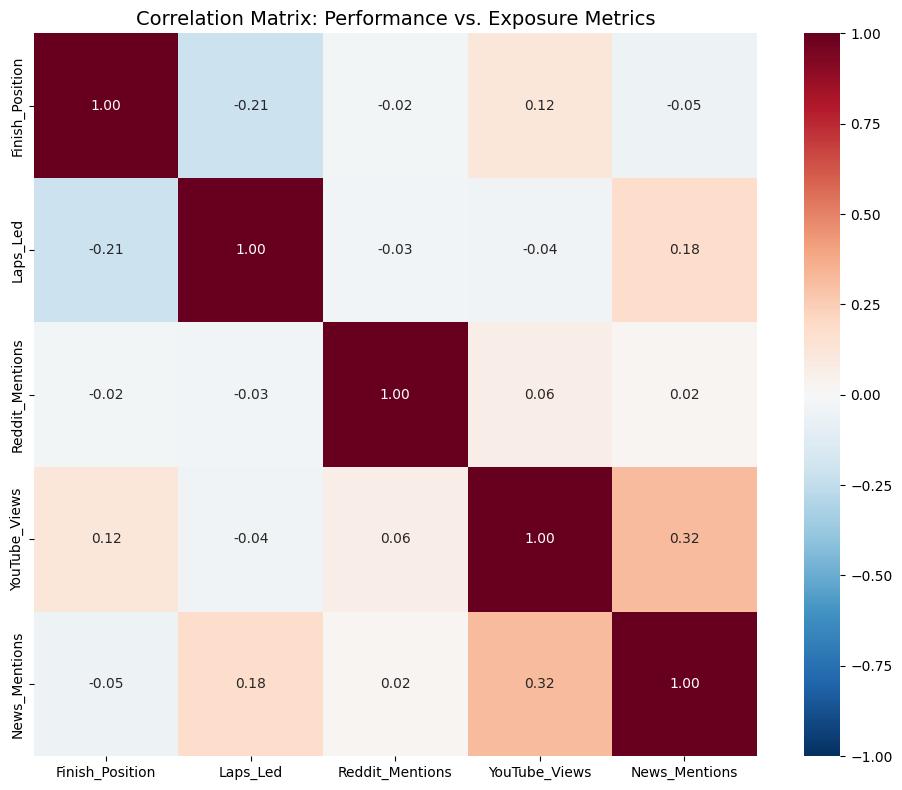

Heatmap saved to output/figures/correlation_heatmap.png


In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, fmt='.2f')
plt.title('Correlation Matrix: Performance vs. Exposure Metrics', fontsize=14)
plt.tight_layout()
plt.savefig('../output/figures/correlation_heatmap.png', dpi=150)
plt.show()
print('Heatmap saved to output/figures/correlation_heatmap.png')

## Step 9: Correlations Within Each Sponsor

In [11]:
sponsor_correlations = []
for sponsor in df['Sponsor'].unique():
    sd = df[df['Sponsor'] == sponsor]
    if len(sd) >= 10:
        cfr, _ = stats.pearsonr(sd['Finish_Position'], sd['Reddit_Mentions'])
        cfy, _ = stats.pearsonr(sd['Finish_Position'], sd['YouTube_Views'])
        cfn, _ = stats.pearsonr(sd['Finish_Position'], sd['News_Mentions'])
        sponsor_correlations.append({'Sponsor': sponsor,
            'Finish_vs_Reddit': round(cfr, 3),
            'Finish_vs_YouTube': round(cfy, 3),
            'Finish_vs_News': round(cfn, 3)})

sponsor_corr_df = pd.DataFrame(sponsor_correlations)
sponsor_corr_df.to_csv('../data/processed/sponsor_correlations.csv', index=False)
sponsor_corr_df

,Sponsor,Finish_vs_Reddit,Finish_vs_YouTube,Finish_vs_News
0,FedEx,0.101,0.107,0.118
1,Love's Travel Stops,-0.331,0.235,0.333
2,McDonald's,0.173,0.135,0.110
3,NAPA Auto Parts,-0.051,0.039,-0.031


## Step 10: Significant Results & Interpretation (feeds the Findings document)

In [12]:
significant = correlation_results[correlation_results['P-Value'] < 0.05].copy()

def interpret_correlation(row):
    corr = row['Correlation']
    strength = 'Strong' if abs(corr) >= 0.7 else 'Moderate' if abs(corr) >= 0.4 else 'Weak'
    direction = 'negative' if corr < 0 else 'positive'
    return f'{strength} {direction}'

if len(significant):
    significant['Interpretation'] = significant.apply(interpret_correlation, axis=1)
print('Statistically Significant Correlations (p < 0.05):')
print(significant.to_string(index=False) if len(significant) else '  (none among finish-position pairs)')

Statistically Significant Correlations (p < 0.05):
Variable 1    Variable 2  Correlation  P-Value Significance Interpretation
  Laps_Led News_Mentions        0.181   0.0301           **  Weak positive


## Step 11: Unexpected Findings & Confounder Checks

In [13]:
print('Unexpected Findings Analysis')
print('-' * 50)
for _, row in correlation_results.iterrows():
    var1, var2 = row['Variable 1'], row['Variable 2']
    corr, pval = row['Correlation'], row['P-Value']
    if 'Position' in var1 and corr > 0:
        print(f'UNEXPECTED: {var1} vs {var2}')
        print(f'  Positive correlation ({corr:+.3f}) suggests worse finishes tie to more exposure.')
        print(f'  Likely explanation: {var2} is race-level (crash/marquee races draw views regardless of our driver).\n')
    if 'Laps_Led' in var1 and pval > 0.10:
        print(f'WEAK: {var1} vs {var2}  (r={corr:+.3f}, p={pval:.4f}) — laps led not driving this channel.\n')

# Daytona dominance check: does one marquee race drive most YouTube exposure?
top_races = (df.groupby(['Race_Number','Race'])['YouTube_Views'].first()
               .sort_values(ascending=False).head(5))
print('Top-5 races by YouTube views (race-level):')
print(top_races)

Unexpected Findings Analysis
--------------------------------------------------
UNEXPECTED: Finish_Position vs YouTube_Views
  Positive correlation (+0.124) suggests worse finishes tie to more exposure.
  Likely explanation: YouTube_Views is race-level (crash/marquee races draw views regardless of our driver).

WEAK: Laps_Led vs Reddit_Mentions  (r=-0.032, p=0.7050) — laps led not driving this channel.

WEAK: Laps_Led vs YouTube_Views  (r=-0.041, p=0.6260) — laps led not driving this channel.

Top-5 races by YouTube views (race-level):
Race_Number  Race     
1            Daytona      120760176.0
3            Las Vegas     87750419.0
10           Talladega     34971366.0
2            Atlanta       13059968.0
24           Michigan      12614339.0
Name: YouTube_Views, dtype: float64


---
## Summary of Findings

| Relationship | r | p-value | Significant? | Interpretation |
|---|---|---|---|---|
| Finish Position vs Reddit | -0.024 | 0.773 | No | No meaningful relationship |
| Finish Position vs YouTube | +0.124 | 0.139 | No | Weak positive (wrong direction) |
| Finish Position vs News | -0.048 | 0.567 | No | No meaningful relationship |
| Laps Led vs Reddit | -0.032 | 0.705 | No | No meaningful relationship |
| Laps Led vs YouTube | -0.041 | 0.626 | No | No meaningful relationship |
| **Laps Led vs News** | **+0.181** | **0.030** | **Yes (**)** | **Weak positive — the one real signal** |

**Bottom line:** Only *Laps Led → News Mentions* is statistically significant (weak, positive).
Finish position shows no significant linear link to any exposure channel at the pooled level,
primarily because Reddit and YouTube were collected at the **race level**, not the sponsor
level. See `docs/correlation_findings.md` for the full write-up feeding the scoring model.
